In [1]:
import numpy as np
from scipy.stats import qmc
import itertools

def generate_edge_midpoints(bounds, max_n):
    """
    Generate structured corner/midpoint particles excluding the center.
    Includes: corners, edge midpoints, face centers.
    Capped at max_n samples.
    """
    bounds = np.array(bounds)
    dim = bounds.shape[0]
    lower = bounds[:, 0]
    upper = bounds[:, 1]
    mid = (lower + upper) / 2

    # Create all 3^d combinations of [low, mid, high]
    levels = [[l, m, u] for l, m, u in zip(lower, mid, upper)]
    full_grid = np.array(list(itertools.product(*levels)))

    # Remove center point
    center = mid
    mask = ~np.all(np.isclose(full_grid, center, rtol=1e-5), axis=1)
    grid_points = full_grid[mask]

    # Deduplicate and cap
    if len(grid_points) > max_n:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(grid_points), size=max_n, replace=False)
        grid_points = grid_points[idx]

    return grid_points


class AdaptivePSO:
    def __init__(self, objective_func, bounds, num_particles=30, num_iterations=100,
                 w_start=0.9, w_end=0.4, c1=2.0, c2=2.0,
                 boundary_trigger_frac=0.8, secondary_frac=0.5,
                 boundary_margin=0.1, seed=None,
                 use_sobol=True, max_edge_points=15,
                 reinject_edges=True):
        self.obj_func = objective_func
        self.bounds = np.array(bounds, dtype=float)
        self.num_particles = num_particles
        self.num_iterations = num_iterations
        self.dim = len(bounds)
        self.w_start = w_start
        self.w_end = w_end
        self.c1 = c1
        self.c2 = c2
        self.boundary_trigger_frac = boundary_trigger_frac
        self.secondary_frac = secondary_frac
        self.boundary_margin = boundary_margin
        self.use_sobol = use_sobol
        self.max_edge_points = max_edge_points
        self.reinject_edges = reinject_edges
        self.rng = np.random.default_rng(seed)

        self.expanded_dims = np.zeros(self.dim, dtype=bool)

        self.positions = self._init_positions()
        self.velocities = self._init_velocities()
        self.personal_best_positions = np.copy(self.positions)
        self.personal_best_scores = self._evaluate(self.positions)
        self.global_best_position = self.personal_best_positions[np.argmin(self.personal_best_scores)]
        self.global_best_score = np.min(self.personal_best_scores)
        self.expansion_log = []

    def _init_positions(self):
        # Generate structured edge/midpoint samples
        edge_particles = generate_edge_midpoints(self.bounds, self.max_edge_points)
        remaining = self.num_particles - len(edge_particles)

        lower, upper = self.bounds[:, 0], self.bounds[:, 1]

        if self.use_sobol:
            sampler = qmc.Sobol(d=self.dim, scramble=True, seed=self.rng.integers(0, 1e9))
        else:
            sampler = qmc.LatinHypercube(d=self.dim, seed=self.rng.integers(0, 1e9))

        sobol_sample = qmc.scale(sampler.random(n=remaining), lower, upper)

        return np.vstack([edge_particles, sobol_sample])

    def _init_velocities(self):
        lower, upper = self.bounds[:, 0], self.bounds[:, 1]
        return self.rng.uniform(-1, 1, size=(self.num_particles, self.dim)) * 0.1 * (upper - lower)

    def _evaluate(self, positions):
        return np.apply_along_axis(self.obj_func, 1, positions)

    def _update_inertia(self, iter_):
        return self.w_start - (self.w_start - self.w_end) * (iter_ / self.num_iterations)

    def _expand_bounds_if_needed(self, best_positions):
        lower, upper = self.bounds[:, 0], self.bounds[:, 1]
        span = upper - lower

        near_lower = best_positions <= (lower + self.boundary_margin * span)
        near_upper = best_positions >= (upper - self.boundary_margin * span)
        near_bounds = np.logical_or(near_lower, near_upper)

        primary_trigger = np.sum(np.any(near_bounds, axis=1)) >= int(self.boundary_trigger_frac * len(best_positions))

        if primary_trigger:
            self.expansion_log.append(self.current_iteration)
            per_dim_counts = np.sum(near_bounds, axis=0)
            secondary_trigger = per_dim_counts >= int(self.secondary_frac * len(best_positions))
            dims_to_check = np.where(np.logical_or(np.any(near_bounds, axis=0), secondary_trigger))[0]
            
            for dim in dims_to_check:
                if np.any(near_lower[:, dim]):
                    delta = 0.5 * span[dim]
                    self.bounds[dim, 0] -= delta
                    self.bounds[dim, 1] -= 0.3 * span[dim]
                    self.expanded_dims[dim] = True
                if np.any(near_upper[:, dim]):
                    delta = 0.5 * span[dim]
                    self.bounds[dim, 1] += delta
                    self.bounds[dim, 0] += 0.3 * span[dim]
                    self.expanded_dims[dim] = True

            if self.reinject_edges:
                edge_points = generate_edge_midpoints(self.bounds, self.max_edge_points * 2)
                mask = np.any([
                    np.isclose(edge_points[:, dim], self.bounds[dim, 0], rtol=1e-3) |
                    np.isclose(edge_points[:, dim], self.bounds[dim, 1], rtol=1e-3)
                    for dim in dims_to_check
                ], axis=0)
                reinjected = edge_points[mask]
                if len(reinjected) > 0:
                    reinjected = reinjected[:min(len(reinjected), self.num_particles // 4)]
                    self.positions[:len(reinjected)] = reinjected
                    self.velocities[:len(reinjected)] = self._init_velocities()[:len(reinjected)]

    def optimize(self, verbose=False):
        for iter_ in range(self.num_iterations):
            self.current_iteration = iter_
            w = self._update_inertia(iter_)
            r1 = self.rng.uniform(size=(self.num_particles, self.dim))
            r2 = self.rng.uniform(size=(self.num_particles, self.dim))
            
            # Get movements
            cognitive = self.c1 * r1 * (self.personal_best_positions - self.positions)
            social = self.c2 * r2 * (self.global_best_position - self.positions)
            self.velocities = w * self.velocities + cognitive + social
            self.positions += self.velocities

            # Clip positions within bounds
            lower, upper = self.bounds[:, 0], self.bounds[:, 1]
            self.positions = np.clip(self.positions, lower, upper)

            scores = self._evaluate(self.positions)
            improved = scores < self.personal_best_scores
            self.personal_best_positions[improved] = self.positions[improved]
            self.personal_best_scores[improved] = scores[improved]

            min_idx = np.argmin(self.personal_best_scores)
            if self.personal_best_scores[min_idx] < self.global_best_score:
                self.global_best_score = self.personal_best_scores[min_idx]
                self.global_best_position = self.personal_best_positions[min_idx]

            best_subset = self.personal_best_positions[np.argsort(self.personal_best_scores)[:10]]
            self._expand_bounds_if_needed(best_subset)

            if verbose and iter_ % 10 == 0:
                print(f"Iter {iter_}: Best score = {self.global_best_score:.5f}")

        return self.global_best_position, self.global_best_score

In [14]:
def multi_minima_function(x):
    """
    Smooth test function with:
    - Global minimum at (2, 2)
    - Local minima at (1.4, 1.4) and (1.2, 1.2)
    """
    x0, x1 = x
    # Base bowl shape
    base = (x0 - 2)**2 + (x1 - 2)**2

    # Add local minima as small negative Gaussians
    local1 = -0.5 * np.exp(-10 * ((x0 - 1.4)**2 + (x1 - 1.4)**2))
    local2 = -0.3 * np.exp(-12 * ((x0 - 1.2)**2 + (x1 - 1.2)**2))

    return base + local1 + local2

# pso = AdaptivePSO(
#     objective_func=multi_minima_function,
#     bounds=[[0, 1], [0, 1]],
#     num_particles=30,
#     num_iterations=100,
#     boundary_trigger_frac=0.8,
#     secondary_frac=0.5,
#     boundary_margin=0.1,
#     seed=42,
#     use_sobol=True,
#     max_edge_points=10,
#     reinject_edges=True
# )

dictreturn = do_PSO(objective_func=multi_minima_function,
    raw_bounds=[[0, 1], [0, 1]],
    num_particles=30,
    num_iterations=100,
    boundary_trigger_frac=0.8,
    secondary_frac=0.5,
    boundary_margin=0.1,
    use_sobol=True,
    max_edge_points=30,
    reinject_edges=True
)

for im in dictreturn:
    print(im, dictreturn[im])
print(dictreturn['best_position'], '\n')

zoomreturn = do_zoomed_PSO(objective_func=multi_minima_function,
    center_point=dictreturn['best_position'], zoom_factor=0.25, 
    raw_bounds=dictreturn['expanded_bounds'], num_particles=20, num_iterations=50, seed=None,
    use_sobol=True, verbose=False)

for im in zoomreturn:
    print(im, zoomreturn[im])

best_position [1.99763425 1.99764639]
best_score -0.0003839332713859858
expanded_bounds [[1.092 2.82 ]
 [1.092 2.82 ]]
expansion_log [0, 1, 2]
pso_instance <__main__.AdaptivePSO object at 0x000001486D9571C0>
[1.99763425 1.99764639] 

best_position [1.99760149 1.99764894]
best_score -0.0003839318836993281
zoom_bounds [[1.78163425 2.21363425]
 [1.78164639 2.21364639]]
pso_instance <__main__.AdaptivePSO object at 0x000001486D957280>


In [15]:
import numpy as np
from scipy.stats import qmc
import itertools

def generate_edge_midpoints(bounds, max_n):
    bounds = np.array(bounds)
    dim = bounds.shape[0]
    lower = bounds[:, 0]
    upper = bounds[:, 1]
    mid = (lower + upper) / 2

    levels = [[l, m, u] for l, m, u in zip(lower, mid, upper)]
    full_grid = np.array(list(itertools.product(*levels)))
    
    center = mid
    mask = ~np.all(np.isclose(full_grid, center, rtol=1e-5), axis=1)
    grid_points = full_grid[mask]

    if len(grid_points) > max_n:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(grid_points), size=max_n, replace=False)
        grid_points = grid_points[idx]

    return grid_points

def scale_to_unit(x_raw, bounds):
    bounds = np.array(bounds)
    return (x_raw - bounds[:, 0]) / (bounds[:, 1] - bounds[:, 0])

def unscale_from_unit(x_unit, bounds):
    bounds = np.array(bounds)
    return bounds[:, 0] + x_unit * (bounds[:, 1] - bounds[:, 0])

class AdaptivePSO:
    def __init__(self, objective_func, bounds, num_particles=30, num_iterations=100,
                 w_start=0.9, w_end=0.4, c1=2.0, c2=2.0,
                 boundary_trigger_frac=0.8, secondary_frac=0.5,
                 boundary_margin=0.1, seed=None,
                 use_sobol=True, max_edge_points=15,
                 reinject_edges=True):

        self.obj_func_raw = objective_func
        self.raw_bounds = np.array(bounds, dtype=float)
        self.bounds = np.array([[0.0, 1.0]] * len(bounds))
        self.num_particles = num_particles
        self.num_iterations = num_iterations
        self.dim = len(bounds)
        self.w_start = w_start
        self.w_end = w_end
        self.c1 = c1
        self.c2 = c2
        self.boundary_trigger_frac = boundary_trigger_frac
        self.secondary_frac = secondary_frac
        self.boundary_margin = boundary_margin
        self.use_sobol = use_sobol
        self.max_edge_points = max_edge_points
        self.reinject_edges = reinject_edges
        self.rng = np.random.default_rng(seed)

        self.expanded_dims = np.zeros(self.dim, dtype=bool)

        self.positions = self._init_positions()
        self.velocities = self._init_velocities()
        self.personal_best_positions = np.copy(self.positions)
        self.personal_best_scores = self._evaluate(self.positions)
        self.global_best_position = self.personal_best_positions[np.argmin(self.personal_best_scores)]
        self.global_best_score = np.min(self.personal_best_scores)
        self.expansion_log = []

    def _init_positions(self):
        edge_particles = generate_edge_midpoints(self.bounds, self.max_edge_points)
        remaining = self.num_particles - len(edge_particles)

        lower, upper = self.bounds[:, 0], self.bounds[:, 1]

        if self.use_sobol:
            sampler = qmc.Sobol(d=self.dim, scramble=True, seed=self.rng.integers(0, 1e9))
        else:
            sampler = qmc.LatinHypercube(d=self.dim, seed=self.rng.integers(0, 1e9))

        sobol_sample = qmc.scale(sampler.random(n=remaining), lower, upper)

        return np.vstack([edge_particles, sobol_sample])

    def _init_velocities(self):
        return self.rng.uniform(-1, 1, size=(self.num_particles, self.dim)) * 0.1

    def _evaluate(self, positions):
        raw_positions = np.apply_along_axis(unscale_from_unit, 1, positions, self.raw_bounds)
        return np.apply_along_axis(self.obj_func_raw, 1, raw_positions)

    def _update_inertia(self, iter_):
        return self.w_start - (self.w_start - self.w_end) * (iter_ / self.num_iterations)

    def _expand_bounds_if_needed(self, best_positions):
        lower, upper = self.bounds[:, 0], self.bounds[:, 1]
        span = upper - lower

        near_lower = best_positions <= (lower + self.boundary_margin * span)
        near_upper = best_positions >= (upper - self.boundary_margin * span)
        near_bounds = np.logical_or(near_lower, near_upper)

        primary_trigger = np.sum(np.any(near_bounds, axis=1)) >= int(self.boundary_trigger_frac * len(best_positions))

        if primary_trigger:
            self.expansion_log.append(self.current_iteration)
            per_dim_counts = np.sum(near_bounds, axis=0)
            secondary_trigger = per_dim_counts >= int(self.secondary_frac * len(best_positions))
            dims_to_check = np.where(np.logical_or(np.any(near_bounds, axis=0), secondary_trigger))[0]

            for dim in dims_to_check:
                if np.any(near_lower[:, dim]):
                    self.bounds[dim, 0] -= 0.5 * span[dim]
                    self.bounds[dim, 1] -= 0.3 * span[dim]
                    self.expanded_dims[dim] = True
                if np.any(near_upper[:, dim]):
                    self.bounds[dim, 1] += 0.5 * span[dim]
                    self.bounds[dim, 0] += 0.3 * span[dim]
                    self.expanded_dims[dim] = True

            if self.reinject_edges:
                edge_points = generate_edge_midpoints(self.bounds, self.max_edge_points * 2)
                mask = np.any([
                    np.isclose(edge_points[:, dim], self.bounds[dim, 0], rtol=1e-3) |
                    np.isclose(edge_points[:, dim], self.bounds[dim, 1], rtol=1e-3)
                    for dim in dims_to_check
                ], axis=0)
                reinjected = edge_points[mask]
                if len(reinjected) > 0:
                    reinjected = reinjected[:min(len(reinjected), self.num_particles // 4)]
                    self.positions[:len(reinjected)] = reinjected
                    self.velocities[:len(reinjected)] = self._init_velocities()[:len(reinjected)]

    def optimize(self, verbose=False):
        for iter_ in range(self.num_iterations):
            self.current_iteration = iter_
            w = self._update_inertia(iter_)
            r1 = self.rng.uniform(size=(self.num_particles, self.dim))
            r2 = self.rng.uniform(size=(self.num_particles, self.dim))

            cognitive = self.c1 * r1 * (self.personal_best_positions - self.positions)
            social = self.c2 * r2 * (self.global_best_position - self.positions)
            self.velocities = w * self.velocities + cognitive + social
            self.positions += self.velocities

            self.positions = np.clip(self.positions, self.bounds[:, 0], self.bounds[:, 1])

            scores = self._evaluate(self.positions)
            improved = scores < self.personal_best_scores
            self.personal_best_positions[improved] = self.positions[improved]
            self.personal_best_scores[improved] = scores[improved]

            min_idx = np.argmin(self.personal_best_scores)
            if self.personal_best_scores[min_idx] < self.global_best_score:
                self.global_best_score = self.personal_best_scores[min_idx]
                self.global_best_position = self.personal_best_positions[min_idx]

            best_subset = self.personal_best_positions[np.argsort(self.personal_best_scores)[:10]]
            self._expand_bounds_if_needed(best_subset)

            if verbose and iter_ % 10 == 0:
                print(f"Iter {iter_}: Best score = {self.global_best_score:.5f}")

        final_unscaled = unscale_from_unit(self.global_best_position, self.raw_bounds)
        return final_unscaled, self.global_best_score
    


In [16]:
def multi_minima_function(x):
    """
    Smooth test function with:
    - Global minimum at (2, 2)
    - Local minima at (1.4, 1.4) and (1.2, 1.2)
    """
    x0, x1 = x
    # Base bowl shape
    base = (x0 - 2)**2 + (x1 - 2)**2

    # Add local minima as small negative Gaussians
    local1 = -0.5 * np.exp(-10 * ((x0 - 1.4)**2 + (x1 - 1.4)**2))
    local2 = -0.3 * np.exp(-12 * ((x0 - 1.2)**2 + (x1 - 1.2)**2))

    return base + local1 + local2

# pso = AdaptivePSO(
#     objective_func=multi_minima_function,
#     bounds=[[0, 1], [0, 1]],
#     num_particles=30,
#     num_iterations=100,
#     boundary_trigger_frac=0.8,
#     secondary_frac=0.5,
#     boundary_margin=0.1,
#     seed=42,
#     use_sobol=True,
#     max_edge_points=10,
#     reinject_edges=True
# )

dictreturn = do_PSO(objective_func=multi_minima_function,
    raw_bounds=[[0, 1], [0, 1]],
    num_particles=30,
    num_iterations=100,
    boundary_trigger_frac=0.8,
    secondary_frac=0.5,
    boundary_margin=0.1,
    use_sobol=True,
    max_edge_points=30,
    reinject_edges=True
)

for im in dictreturn:
    print(im, dictreturn[im])
print(dictreturn['best_position'], '\n')

zoomreturn = do_zoomed_PSO(objective_func=multi_minima_function,
    center_point=dictreturn['best_position'], zoom_factor=0.25, 
    raw_bounds=dictreturn['expanded_bounds'], num_particles=20, num_iterations=50, seed=None,
    use_sobol=True, verbose=False)

for im in zoomreturn:
    print(im, zoomreturn[im])

best_position [1.99763873 1.99763882]
best_score -0.00038393335116350104
expanded_bounds [[1.092 2.82 ]
 [1.092 2.82 ]]
expansion_log [0, 1, 2]
pso_instance <__main__.AdaptivePSO object at 0x000001486BDCD3D0>
[1.99763873 1.99763882] 

best_position [1.99763743 1.9976549 ]
best_score -0.00038393308848598756
zoom_bounds [[1.78163873 2.21363873]
 [1.78163882 2.21363882]]
pso_instance <__main__.AdaptivePSO object at 0x000001486BDCD730>


In [22]:
### PREVIOUS WORKING MODEL

import numpy as np
from scipy.stats import qmc
import itertools

def generate_edge_midpoints(bounds, max_n):
    bounds = np.array(bounds)
    dim = bounds.shape[0]
    lower = bounds[:, 0]
    upper = bounds[:, 1]
    mid = (lower + upper) / 2

    levels = [[l, m, u] for l, m, u in zip(lower, mid, upper)]
    full_grid = np.array(list(itertools.product(*levels)))

    center = mid
    mask = ~np.all(np.isclose(full_grid, center, rtol=1e-5), axis=1)
    grid_points = full_grid[mask]

    if len(grid_points) > max_n:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(grid_points), size=max_n, replace=False)
        grid_points = grid_points[idx]

    return grid_points

def scale_to_unit(x_raw, bounds):
    bounds = np.array(bounds)
    return (x_raw - bounds[:, 0]) / (bounds[:, 1] - bounds[:, 0])

def unscale_from_unit(x_unit, bounds):
    bounds = np.array(bounds)
    return bounds[:, 0] + x_unit * (bounds[:, 1] - bounds[:, 0])

class AdaptivePSO:
    def __init__(self, objective_func, bounds, num_particles=30, num_iterations=100,
                 w_start=0.9, w_end=0.4, c1=2.0, c2=2.0,
                 boundary_trigger_frac=0.8, secondary_frac=0.5,
                 boundary_margin=0.1, seed=None,
                 use_sobol=True, max_edge_points=15,
                 reinject_edges=True):

        self.obj_func_raw = objective_func
        self.raw_bounds = np.array(bounds, dtype=float)
        self.bounds = np.array([[0.0, 1.0]] * len(bounds))
        self.num_particles = num_particles
        self.num_iterations = num_iterations
        self.dim = len(bounds)
        self.w_start = w_start
        self.w_end = w_end
        self.c1 = c1
        self.c2 = c2
        self.boundary_trigger_frac = boundary_trigger_frac
        self.secondary_frac = secondary_frac
        self.boundary_margin = boundary_margin
        self.use_sobol = use_sobol
        self.max_edge_points = max_edge_points
        self.reinject_edges = reinject_edges
        self.rng = np.random.default_rng(seed)

        self.expanded_dims = np.zeros(self.dim, dtype=bool)
        # self.iteration_offset = 0  # Tracks iteration reset offset for inertia update

        self.positions = self._init_positions()
        self.velocities = self._init_velocities()
        self.personal_best_positions = np.copy(self.positions)
        self.personal_best_scores = self._evaluate(self.positions)
        self.global_best_position = self.personal_best_positions[np.argmin(self.personal_best_scores)]
        self.global_best_score = np.min(self.personal_best_scores)
        self.expansion_log = []

    def _init_positions(self):
        edge_particles = generate_edge_midpoints(self.bounds, self.max_edge_points)
        remaining = self.num_particles - len(edge_particles)

        lower, upper = self.bounds[:, 0], self.bounds[:, 1]

        if self.use_sobol:
            sampler = qmc.Sobol(d=self.dim, scramble=True, seed=self.rng.integers(0, 1e9))
        else:
            sampler = qmc.LatinHypercube(d=self.dim, seed=self.rng.integers(0, 1e9))

        sobol_sample = qmc.scale(sampler.random(n=remaining), lower, upper)

        return np.vstack([edge_particles, sobol_sample])

    def _init_velocities(self):
        return self.rng.uniform(-1, 1, size=(self.num_particles, self.dim)) * 0.1

    def _evaluate(self, positions):
        raw_positions = np.apply_along_axis(unscale_from_unit, 1, positions, self.raw_bounds)
        return np.apply_along_axis(self.obj_func_raw, 1, raw_positions)

    def _update_inertia(self, iter_):
        return self.w_start - (self.w_start - self.w_end) * (iter_ / self.num_iterations)
    
#     def _update_inertia(self, iter_):
#         effective_iter = iter_ - self.iteration_offset
#         if effective_iter < 0:
#             effective_iter = 0
#         return self.w_start - (self.w_start - self.w_end) * (effective_iter / self.num_iterations)

    def _expand_bounds_if_needed(self, best_positions):
        lower, upper = self.bounds[:, 0], self.bounds[:, 1]
        span = upper - lower

        near_lower = best_positions <= (lower + self.boundary_margin * span)
        near_upper = best_positions >= (upper - self.boundary_margin * span)
        near_bounds = np.logical_or(near_lower, near_upper)

        primary_trigger = np.sum(np.any(near_bounds, axis=1)) >= int(self.boundary_trigger_frac * len(best_positions))

        if primary_trigger:
            self.expansion_log.append(self.current_iteration)
            
#             ### These lines need testing
#             # Reset iteration offset to current iteration to restart inertia decay
#             self.iteration_offset = self.current_iteration

#             # Optional: reinitialize velocities to promote exploration
#             self.velocities = self._init_velocities()
            
            
            per_dim_counts = np.sum(near_bounds, axis=0)
            secondary_trigger = per_dim_counts >= int(self.secondary_frac * len(best_positions))
            dims_to_check = np.where(np.logical_or(np.any(near_bounds, axis=0), secondary_trigger))[0]

            for dim in dims_to_check:
                if np.any(near_lower[:, dim]):
                    self.bounds[dim, 0] -= 0.5 * span[dim]
                    self.bounds[dim, 1] -= 0.3 * span[dim]
                    self.expanded_dims[dim] = True
                if np.any(near_upper[:, dim]):
                    self.bounds[dim, 1] += 0.5 * span[dim]
                    self.bounds[dim, 0] += 0.3 * span[dim]
                    self.expanded_dims[dim] = True

                # Ensure bounds are valid
                if self.bounds[dim, 1] < self.bounds[dim, 0]:
                    midpoint = np.mean(self.bounds[dim])
                    delta = 0.1 * abs(span[dim])
                    self.bounds[dim] = [midpoint - delta, midpoint + delta]

            if self.reinject_edges:
                edge_points = generate_edge_midpoints(self.bounds, self.max_edge_points * 2)
                mask = np.any([
                    np.isclose(edge_points[:, dim], self.bounds[dim, 0], rtol=1e-3) |
                    np.isclose(edge_points[:, dim], self.bounds[dim, 1], rtol=1e-3)
                    for dim in dims_to_check
                ], axis=0)
                reinjected = edge_points[mask]
                if len(reinjected) > 0:
                    reinjected = reinjected[:min(len(reinjected), self.num_particles // 4)]

                    elite_indices = np.argsort(self.personal_best_scores)[:len(reinjected)]
                    non_elite_indices = np.setdiff1d(np.arange(self.num_particles), elite_indices)[:len(reinjected)]

                    self.positions[non_elite_indices] = reinjected
                    self.velocities[non_elite_indices] = self._init_velocities()[:len(reinjected)]

    def optimize(self, verbose=False):
        for iter_ in range(self.num_iterations):
            self.current_iteration = iter_
            w = self._update_inertia(iter_)
            r1 = self.rng.uniform(size=(self.num_particles, self.dim))
            r2 = self.rng.uniform(size=(self.num_particles, self.dim))

            cognitive = self.c1 * r1 * (self.personal_best_positions - self.positions)
            social = self.c2 * r2 * (self.global_best_position - self.positions)
            self.velocities = w * self.velocities + cognitive + social
            self.positions += self.velocities

            self.positions = np.clip(self.positions, self.bounds[:, 0], self.bounds[:, 1])

            scores = self._evaluate(self.positions)
            improved = scores < self.personal_best_scores
            self.personal_best_positions[improved] = self.positions[improved]
            self.personal_best_scores[improved] = scores[improved]

            min_idx = np.argmin(self.personal_best_scores)
            if self.personal_best_scores[min_idx] < self.global_best_score:
                self.global_best_score = self.personal_best_scores[min_idx]
                self.global_best_position = self.personal_best_positions[min_idx]

            best_subset = self.personal_best_positions[np.argsort(self.personal_best_scores)[:10]]
            self._expand_bounds_if_needed(best_subset)

            if verbose and iter_ % 10 == 0:
                print(f"Iter {iter_}: Best score = {self.global_best_score:.5f}")

        final_unscaled = unscale_from_unit(self.global_best_position, self.raw_bounds)
        return final_unscaled, self.global_best_score


def multi_minima_function(x):
    """
    Smooth test function with:
    - Global minimum at (2, 2)
    - Local minima at (1.4, 1.4) and (1.2, 1.2)
    """
    x0, x1 = x
    # Base bowl shape
    base = (x0 - 2)**2 + (x1 - 2)**2

    # Add local minima as small negative Gaussians
    local1 = -0.5 * np.exp(-10 * ((x0 - 1.4)**2 + (x1 - 1.4)**2))
    local2 = -0.3 * np.exp(-12 * ((x0 - 1.2)**2 + (x1 - 1.2)**2))

    return base + local1 + local2

# pso = AdaptivePSO(
#     objective_func=multi_minima_function,
#     bounds=[[0, 1], [0, 1]],
#     num_particles=30,
#     num_iterations=100,
#     boundary_trigger_frac=0.8,
#     secondary_frac=0.5,
#     boundary_margin=0.1,
#     seed=42,
#     use_sobol=True,
#     max_edge_points=10,
#     reinject_edges=True
# )

dictreturn = do_PSO(objective_func=multi_minima_function,
    raw_bounds=[[0, 1], [0, 1]],
    num_particles=40,
    num_iterations=100,
    boundary_trigger_frac=0.8,
    secondary_frac=0.5,
    boundary_margin=0.1,
    use_sobol=True,
    max_edge_points=30,
    reinject_edges=True
)

for im in dictreturn:
    print(im, dictreturn[im])
print(dictreturn['best_position'], '\n')

zoomreturn = do_zoomed_PSO(objective_func=multi_minima_function,
    center_point=dictreturn['best_position'], zoom_factor=0.25, 
    raw_bounds=dictreturn['expanded_bounds'], num_particles=50, num_iterations=50, seed=None,
    use_sobol=True, verbose=False)

for im in zoomreturn:
    print(im, zoomreturn[im])

best_position [1.99763931 1.99763896]
best_score -0.0003839333505762307
expanded_bounds [[1.092 2.82 ]
 [1.092 2.82 ]]
expansion_log [0, 1, 2]
pso_instance <__main__.AdaptivePSO object at 0x0000014853397BE0>
[1.99763931 1.99763896] 

best_position [1.99762817 1.99762543]
best_score -0.00038393308540098146
zoom_bounds [[1.78163931 2.21363931]
 [1.78163896 2.21363896]]
pso_instance <__main__.AdaptivePSO object at 0x0000014853397D60>


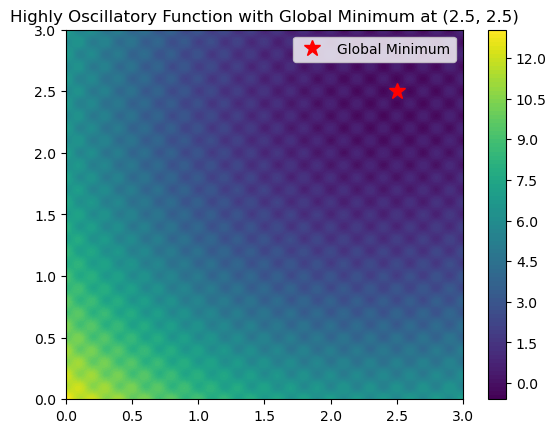

In [3]:
import numpy as np

def oscillatory_function(x):
    """
    Highly oscillatory 2D function with:
    - A global minimum at (2.5, 2.5)
    - Many local minima in [0, 1] x [0, 1]
    """
    x0, x1 = x
    # High-frequency cosine waves create many local minima in [0,1]x[0,1]
    local_field = np.cos(10 * np.pi * x0) * np.cos(10 * np.pi * x1)

    # Base hill: ensures global minimum isn't in initial region
    hill = (x0 - 2.5)**2 + (x1 - 2.5)**2

    # Combine: global minimum at (2.5, 2.5), field adds many local traps
    return hill + 0.5 * local_field

import matplotlib.pyplot as plt

x = np.linspace(0, 3, 300)
y = np.linspace(0, 3, 300)
X, Y = np.meshgrid(x, y)
Z = (X - 2.5)**2 + (Y - 2.5)**2 + 0.5 * np.cos(10 * np.pi * X) * np.cos(10 * np.pi * Y)

plt.contourf(X, Y, Z, levels=100, cmap='viridis')
plt.plot(2.5, 2.5, 'r*', markersize=12, label='Global Minimum')
plt.colorbar()
plt.title("Highly Oscillatory Function with Global Minimum at (2.5, 2.5)")
plt.legend()
plt.show()


In [26]:
dictreturn = do_PSO(
    objective_func=oscillatory_function,
    raw_bounds=[[0, 1], [0, 1]],
    num_particles=40,
    num_iterations=100,
    boundary_trigger_frac=0.7,
    secondary_frac=0.5,
    boundary_margin=0.1,
    seed=123,
    use_sobol=True,
    max_edge_points=20,
    reinject_edges=True
)

# Zoom in around the best
zoomreturn = do_zoomed_PSO(
    objective_func=oscillatory_function,
    center_point=dictreturn['best_position'],
    zoom_factor=0.25,
    raw_bounds=dictreturn['expanded_bounds'],
    num_particles=30,
    num_iterations=50,
    seed=999,
    use_sobol=True,
    verbose=True
)

for im in dictreturn:
    print(im, dictreturn[im])
print(dictreturn['best_position'], '\n')

for im in zoomreturn:
    print(im, zoomreturn[im])

Iter 0: Best score = -0.44483
Iter 10: Best score = -0.48817
Iter 20: Best score = -0.48817
Iter 30: Best score = -0.48952
Iter 40: Best score = -0.48998
best_position [2.40036484 2.49992305]
best_score -0.49003852523193564
expanded_bounds [[1.6104 3.684 ]
 [1.6104 3.684 ]]
expansion_log [0, 1, 2, 3]
pso_instance <__main__.AdaptivePSO object at 0x000001486EBBB880>
[2.40036484 2.49992305] 

best_position [2.50003696 2.59939299]
best_score -0.4900297840056865
zoom_bounds [[2.14116484 2.65956484]
 [2.24072305 2.75912305]]
pso_instance <__main__.AdaptivePSO object at 0x000001486D01AB20>


In [36]:
dictreturn = do_PSO(
    objective_func=oscillatory_function,
    raw_bounds=[[0, 1], [0, 1]],
    num_particles=100,
    num_iterations=100,
    boundary_trigger_frac=0.7,
    secondary_frac=0.5,
    boundary_margin=0.1,
    seed=123,
    use_sobol=True,
    max_edge_points=26,
    reinject_edges=True
)

# Zoom in around the best
zoomreturn = do_zoomed_PSO(
    objective_func=oscillatory_function,
    center_point=dictreturn['best_position'],
    zoom_factor=0.25,
    raw_bounds=dictreturn['expanded_bounds'],
    num_particles=100,
    num_iterations=100,
    seed=999,
    use_sobol=True,
    max_edge_points=26,
    verbose=True
)

for im in dictreturn:
    print(im, dictreturn[im])
print(dictreturn['best_position'], '\n')

for im in zoomreturn:
    print(im, zoomreturn[im])

Iter 0: Best score = -0.43298
Iter 10: Best score = -0.48094
Iter 20: Best score = -0.48348
Iter 30: Best score = -0.48513
Iter 40: Best score = -0.48949
Iter 50: Best score = -0.48949
Iter 60: Best score = -0.48958
Iter 70: Best score = -0.48964
Iter 80: Best score = -0.48999
Iter 90: Best score = -0.49003
best_position [2.50000218 2.59959506]
best_score -0.4900403638400025
expanded_bounds [[1.6104 3.684 ]
 [1.6104 3.684 ]]
expansion_log [0, 1, 2, 3]
pso_instance <__main__.AdaptivePSO object at 0x000001486EA86850>
[2.50000218 2.59959506] 

best_position [2.49995406 2.4003524 ]
best_score -0.4900391916203389
zoom_bounds [[2.24080218 2.75920218]
 [2.34039506 2.85879506]]
pso_instance <__main__.AdaptivePSO object at 0x000001486EA869D0>


In [75]:
### CURRENT WORKING MODEL

import numpy as np
from scipy.stats import qmc
import itertools

def generate_edge_midpoints(bounds, max_n):
    bounds = np.array(bounds)
    dim = bounds.shape[0]
    lower = bounds[:, 0]
    upper = bounds[:, 1]
    mid = (lower + upper) / 2

    levels = [[l, m, u] for l, m, u in zip(lower, mid, upper)]
    full_grid = np.array(list(itertools.product(*levels)))

    center = mid
    mask = ~np.all(np.isclose(full_grid, center, rtol=1e-5), axis=1)
    grid_points = full_grid[mask]

    if len(grid_points) > max_n:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(grid_points), size=max_n, replace=False)
        grid_points = grid_points[idx]

    return grid_points

def scale_to_unit(x_raw, bounds):
    bounds = np.array(bounds)
    return (x_raw - bounds[:, 0]) / (bounds[:, 1] - bounds[:, 0])

def unscale_from_unit(x_unit, bounds):
    bounds = np.array(bounds)
    return bounds[:, 0] + x_unit * (bounds[:, 1] - bounds[:, 0])

class AdaptivePSO:
    def __init__(self, objective_func, bounds, num_particles=30, num_iterations=100,
                 w_start=0.9, w_end=0.4, c1=2.0, c2=2.0, num_best = 10,
                 boundary_trigger_frac=0.8, secondary_frac=0.5,
                 boundary_margin=0.1, seed=None,
                 use_sobol=True, max_edge_points=15,
                 reinject_edges=True):

        self.obj_func_raw = objective_func
        self.raw_bounds = np.array(bounds, dtype=float)
        self.bounds = np.array([[0.0, 1.0]] * len(bounds))
        self.num_particles = num_particles
        self.num_iterations = num_iterations
        self.dim = len(bounds)
        self.w_start = w_start
        self.w_end = w_end
        self.c1 = c1
        self.c2 = c2
        self.num_best = num_best
        self.boundary_trigger_frac = boundary_trigger_frac
        self.secondary_frac = secondary_frac
        self.boundary_margin = boundary_margin
        self.use_sobol = use_sobol
        self.max_edge_points = max_edge_points
        self.reinject_edges = reinject_edges
        self.rng = np.random.default_rng(seed)

        self.expanded_dims = np.zeros(self.dim, dtype=bool)
        self.iteration_offset = 0  # Tracks iteration reset offset for inertia update
        self.reset_generations = False

        self.positions = self._init_positions()
        self.velocities = self._init_velocities()
        self.personal_best_positions = np.copy(self.positions)
        self.personal_best_scores = self._evaluate(self.positions)
        self.global_best_position = self.personal_best_positions[np.argmin(self.personal_best_scores)]
        self.global_best_score = np.min(self.personal_best_scores)
        self.expansion_log = []

    def _init_positions(self):
        edge_particles = generate_edge_midpoints(self.bounds, self.max_edge_points)
        remaining = self.num_particles - len(edge_particles)

        lower, upper = self.bounds[:, 0], self.bounds[:, 1]

        if self.use_sobol:
            sampler = qmc.Sobol(d=self.dim, scramble=True, seed=self.rng.integers(0, 1e9))
        else:
            sampler = qmc.LatinHypercube(d=self.dim, seed=self.rng.integers(0, 1e9))

        sobol_sample = qmc.scale(sampler.random(n=remaining), lower, upper)

        return np.vstack([edge_particles, sobol_sample])

    def _init_velocities(self):
        return self.rng.uniform(-1, 1, size=(self.num_particles, self.dim)) * 0.1

    def _evaluate(self, positions):
        raw_positions = np.apply_along_axis(unscale_from_unit, 1, positions, self.raw_bounds)
        return np.apply_along_axis(self.obj_func_raw, 1, raw_positions)

#     def _update_inertia(self, iter_):
#         return self.w_start - (self.w_start - self.w_end) * (iter_ / self.num_iterations)
    
    def _update_inertia(self, iter_):
        effective_iter = iter_ - self.iteration_offset
        if effective_iter < 0:
            effective_iter = 0
        return self.w_start - (self.w_start - self.w_end) * (effective_iter / self.num_iterations)

    def _expand_bounds_if_needed(self, best_positions):
        lower, upper = self.bounds[:, 0], self.bounds[:, 1]
        span = upper - lower

        near_lower = best_positions <= (lower + self.boundary_margin * span)
        near_upper = best_positions >= (upper - self.boundary_margin * span)
        near_bounds = np.logical_or(near_lower, near_upper)

        primary_trigger = np.sum(np.any(near_bounds, axis=1)) >= int(self.boundary_trigger_frac * len(best_positions))

        if primary_trigger:
            self.expansion_log.append(self.current_iteration)
            
            ### These lines need testing
            # Reset iteration offset to current iteration to restart inertia decay
            self.iteration_offset = self.current_iteration
            self.reset_generations = True

            # Optional: reinitialize velocities to promote exploration
            self.velocities = self._init_velocities()
            
            
            per_dim_counts = np.sum(near_bounds, axis=0)
            secondary_trigger = per_dim_counts >= int(self.secondary_frac * len(best_positions))
            dims_to_check = np.where(np.logical_or(np.any(near_bounds, axis=0), secondary_trigger))[0]

            for dim in dims_to_check:
                if np.any(near_lower[:, dim]):
                    self.bounds[dim, 0] -= 0.5 * span[dim]
                    self.bounds[dim, 1] -= 0.3 * span[dim]
                    self.expanded_dims[dim] = True
                if np.any(near_upper[:, dim]):
                    self.bounds[dim, 1] += 0.5 * span[dim]
                    self.bounds[dim, 0] += 0.3 * span[dim]
                    self.expanded_dims[dim] = True

                # Ensure bounds are valid
                if self.bounds[dim, 1] < self.bounds[dim, 0]:
                    midpoint = np.mean(self.bounds[dim])
                    delta = 0.1 * abs(span[dim])
                    self.bounds[dim] = [midpoint - delta, midpoint + delta]

            if self.reinject_edges:
                edge_points = generate_edge_midpoints(self.bounds, self.max_edge_points * 2)
                mask = np.any([
                    np.isclose(edge_points[:, dim], self.bounds[dim, 0], rtol=1e-3) |
                    np.isclose(edge_points[:, dim], self.bounds[dim, 1], rtol=1e-3)
                    for dim in dims_to_check
                ], axis=0)
                reinjected = edge_points[mask]
                if len(reinjected) > 0:
                    reinjected = reinjected[:min(len(reinjected), self.num_particles // 4)]

                    elite_indices = np.argsort(self.personal_best_scores)[:len(reinjected)]
                    non_elite_indices = np.setdiff1d(np.arange(self.num_particles), elite_indices)[:len(reinjected)]

                    self.positions[non_elite_indices] = reinjected
                    self.velocities[non_elite_indices] = self._init_velocities()[:len(reinjected)]

    def optimize(self, verbose=False):
        # for iter_ in range(self.num_iterations):
        generations_since_expansion = 0
        total_generations_done = 0
        max_total_generations = 100000  # safety cap to avoid infinite loop

        while generations_since_expansion < self.num_iterations and total_generations_done < max_total_generations:
            self.current_iteration = generations_since_expansion
            w = self._update_inertia(generations_since_expansion)
            r1 = self.rng.uniform(size=(self.num_particles, self.dim))
            r2 = self.rng.uniform(size=(self.num_particles, self.dim))

            cognitive = self.c1 * r1 * (self.personal_best_positions - self.positions)
            social = self.c2 * r2 * (self.global_best_position - self.positions)
            self.velocities = w * self.velocities + cognitive + social
            self.positions += self.velocities

            self.positions = np.clip(self.positions, self.bounds[:, 0], self.bounds[:, 1])

            scores = self._evaluate(self.positions)
            improved = scores < self.personal_best_scores
            self.personal_best_positions[improved] = self.positions[improved]
            self.personal_best_scores[improved] = scores[improved]

            min_idx = np.argmin(self.personal_best_scores)
            if self.personal_best_scores[min_idx] < self.global_best_score:
#                 self.iteration_offset = self.current_iteration  # reset inertia schedule
#                 self.reset_generations = True
                self.global_best_score = self.personal_best_scores[min_idx]
                self.global_best_position = self.personal_best_positions[min_idx]

            best_subset = self.personal_best_positions[np.argsort(self.personal_best_scores)[:self.num_best]]
            self._expand_bounds_if_needed(best_subset)
            
            if getattr(self, "reset_generations", False):
                generations_since_expansion = 0
                self.reset_generations = False

            if verbose and generations_since_expansion % 10 == 0:
                print(f"Iter {total_generations_done}: Best score = {self.global_best_score:.5f}")
                
            generations_since_expansion += 1
            total_generations_done += 1

        final_unscaled = unscale_from_unit(self.global_best_position, self.raw_bounds)
        return final_unscaled, self.global_best_score


def multi_minima_function(x):
    """
    Smooth test function with:
    - Global minimum at (2, 2)
    - Local minima at (1.4, 1.4) and (1.2, 1.2)
    """
    x0, x1 = x
    # Base bowl shape
    base = (x0 - 5000)**2 + (x1 - 5000)**2

    # Add local minima as small negative Gaussians
    local1 = -0.5 * np.exp(-10 * ((x0 - 1.4)**2 + (x1 - 1.4)**2))
    local2 = -0.3 * np.exp(-12 * ((x0 - 1.2)**2 + (x1 - 1.2)**2))

    return base + local1 + local2

# pso = AdaptivePSO(
#     objective_func=multi_minima_function,
#     bounds=[[0, 1], [0, 1]],
#     num_particles=30,
#     num_iterations=100,
#     boundary_trigger_frac=0.8,
#     secondary_frac=0.5,
#     boundary_margin=0.1,
#     seed=42,
#     use_sobol=True,
#     max_edge_points=10,
#     reinject_edges=True
# )

dictreturn = do_PSO(objective_func=multi_minima_function,
    raw_bounds=[[0, 1], [0, 1]],
    num_particles=40,
    num_iterations=100,
    num_best = 15,
    boundary_trigger_frac=0.8,
    secondary_frac=0.5,
    boundary_margin=0.1,
    use_sobol=True,
    max_edge_points=30,
    reinject_edges=True
)

for im in dictreturn:
    print(im, dictreturn[im])
print(dictreturn['best_position'], '\n')

zoomreturn = do_zoomed_PSO(objective_func=multi_minima_function,
    center_point=dictreturn['best_position'], zoom_factor=0.25, 
    raw_bounds=dictreturn['expanded_bounds'], num_particles=50, num_iterations=50, seed=None,
    use_sobol=True, verbose=False)

for im in zoomreturn:
    print(im, zoomreturn[im])

NameError: name 'bounds' is not defined

In [65]:
dictreturn = do_PSO(objective_func=oscillatory_function,
    raw_bounds=[[0, 1], [0, 1]],
    num_particles=40,
    num_iterations=100,
    num_best = 15,
    boundary_trigger_frac=0.8,
    secondary_frac=0.5,
    boundary_margin=0.1,
    use_sobol=True,
    max_edge_points=10,
    reinject_edges=True
)

for im in dictreturn:
    print(im, dictreturn[im])
print(dictreturn['best_position'], '\n')

zoomreturn = do_zoomed_PSO(objective_func=oscillatory_function,
    center_point=dictreturn['best_position'], zoom_factor=0.25, 
    raw_bounds=dictreturn['expanded_bounds'], num_particles=50, num_iterations=50, seed=None,
    max_edge_points=26,use_sobol=True, verbose=False)

for im in zoomreturn:
    print(im, zoomreturn[im])
    
print(oscillatory_function([2.5,2.5]))
print(oscillatory_function([2.5,2.6]))

best_position [2.59959636 2.49999998]
best_score -0.49004036541930357
expanded_bounds [[1.6104 3.684 ]
 [1.6104 3.684 ]]
expansion_log [0, 2, 2, 6]
pso_instance <__main__.AdaptivePSO object at 0x000001486E7C7190>
[2.59959636 2.49999998] 

best_position [2.40040846 2.49999974]
best_score -0.49004035970470056
zoom_bounds [[2.34039636 2.85879636]
 [2.24079998 2.75919998]]
pso_instance <__main__.AdaptivePSO object at 0x000001486E7C71F0>
0.5
-0.49


In [1]:
def do_PSO(objective_func, bounds, num_particles=30, num_iterations=100, c1=2.0, c2=2.0,
           num_best=10, boundary_trigger_frac=0.8, secondary_frac=0.5, boundary_margin=0.1,
           use_sobol=True, max_edge_points=30, reinject_edges=True,
           seed=None, verbose=False):
    """
    Primary wrapper for AdaptivePSO. Handles initial search with boundary expansions.
    """
    # from adaptive_pso import AdaptivePSO  # If using an external file

    pso = AdaptivePSO(
        objective_func=objective_func,
        bounds=bounds,
        num_particles=num_particles,
        num_iterations=num_iterations,
        c1=1.0,
        c2=2.0,
        num_best=num_best,
        boundary_trigger_frac=boundary_trigger_frac,
        secondary_frac=secondary_frac,
        boundary_margin=boundary_margin,
        use_sobol=use_sobol,
        max_edge_points=max_edge_points,
        reinject_edges=reinject_edges,
        seed=seed
    )

    best_position, best_score = pso.optimize(verbose=verbose)
    return {
        'best_position': best_position,
        'best_score': best_score,
        'expanded_bounds': pso.raw_bounds,
        'expansion_log': pso.expansion_log,
        'pso_instance': pso
    }

def do_zoomed_PSO(objective_func, center_point, zoom_factor=0.25, raw_bounds=None, num_particles=30, 
           num_iterations=100, c1=1.0, c2=2.0, num_best=10, boundary_trigger_frac=0.8, secondary_frac=0.5,
           boundary_margin=0.1, use_sobol=True, max_edge_points=26, reinject_edges=True,
           seed=None, verbose=False):

#     def do_zoomed_PSO(objective_func, center_point, zoom_factor=0.25, raw_bounds=None,
#                       num_particles=20, num_iterations=50, seed=None,
#                       use_sobol=True, verbose=False):
    """
    Zoomed-in local PSO search centered on `center_point`, using a percentage zoom_factor.
    """
    dim = len(center_point)
    center_point = np.array(center_point)

    if raw_bounds is None:
        raise ValueError("Must pass raw_bounds to do_zoomed_PSO to clip new search region.")

    raw_bounds = np.array(raw_bounds)
    lower_clip, upper_clip = raw_bounds[:, 0], raw_bounds[:, 1]

    span = (upper_clip - lower_clip) * zoom_factor
    local_lower = np.maximum(center_point - span / 2, lower_clip)
    local_upper = np.minimum(center_point + span / 2, upper_clip)
    zoom_bounds = np.stack([local_lower, local_upper], axis=1)

    # from adaptive_pso import AdaptivePSO  # If using an external file
    pso = AdaptivePSO(
        objective_func=objective_func,
        bounds=zoom_bounds,
        num_particles=num_particles,
        num_iterations=num_iterations,
        c1=1.0,
        c2=2.0,
        num_best=num_best,
        boundary_trigger_frac=boundary_trigger_frac,
        secondary_frac=secondary_frac,
        boundary_margin=boundary_margin,
        use_sobol=use_sobol,
        max_edge_points=max_edge_points,
        reinject_edges=reinject_edges,
        seed=seed
    )

    best_position, best_score = pso.optimize(verbose=verbose)
    return {
        'best_position': best_position,
        'best_score': best_score,
        'zoom_bounds': zoom_bounds,
        'pso_instance': pso
    }

In [7]:
import numpy as np
from scipy.stats import qmc
import itertools

def generate_edge_midpoints(bounds, max_n):
    bounds = np.array(bounds)
    dim = bounds.shape[0]
    lower = bounds[:, 0]
    upper = bounds[:, 1]
    mid = (lower + upper) / 2

    levels = [[l, m, u] for l, m, u in zip(lower, mid, upper)]
    full_grid = np.array(list(itertools.product(*levels)))

    center = mid
    mask = ~np.all(np.isclose(full_grid, center, rtol=1e-5), axis=1)
    grid_points = full_grid[mask]

    if len(grid_points) > max_n:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(grid_points), size=max_n, replace=False)
        grid_points = grid_points[idx]

    return grid_points

def scale_to_unit(x_raw, bounds):
    bounds = np.array(bounds)
    return (x_raw - bounds[:, 0]) / (bounds[:, 1] - bounds[:, 0])

def unscale_from_unit(x_unit, bounds):
    bounds = np.array(bounds)
    print('bounds:', bounds)
    print('bounds[:, 0]:', bounds[:, 0])
    print('bounds[:, 1]:', bounds[:, 1])
    print('(bounds[:, 1] - bounds[:, 0]):', (bounds[:, 1] - bounds[:, 0]))
    return bounds[:, 0] + x_unit * (bounds[:, 1] - bounds[:, 0])

class AdaptivePSO:
    def __init__(self, objective_func, bounds, num_particles=100, num_iterations=100,
                 w_start=0.9, w_end=0.4, c1=2.0, c2=2.0, num_best = 10,
                 boundary_trigger_frac=0.8, secondary_frac=0.5, boundary_margin=0.1, seed=None,
                 use_sobol=True, max_edge_points=26, reinject_edges=True, max_velocity_init=0.2,
                 max_velocity_final_factor=0.5):

        self.obj_func_raw = objective_func
        self.raw_bounds = np.array(bounds, dtype=float)
        self.bounds = np.array([[0.0, 1.0]] * len(bounds))
        self.num_particles = num_particles
        self.num_iterations = num_iterations
        self.dim = len(bounds)
        self.w_start = w_start
        self.w_end = w_end
        self.c1 = c1
        self.c2 = c2
        self.num_best = num_best
        self.boundary_trigger_frac = boundary_trigger_frac
        self.secondary_frac = secondary_frac
        self.boundary_margin = boundary_margin
        self.use_sobol = use_sobol
        self.max_edge_points = max_edge_points
        self.reinject_edges = reinject_edges
        self.rng = np.random.default_rng(seed)
        self.max_velocity_init=max_velocity_init
        self.max_velocity_final_factor=max_velocity_final_factor

        self.expanded_dims = np.zeros(self.dim, dtype=bool)
        self.reset_generations = False

        self.positions = self._init_positions()
        self.velocities = self._init_velocities()
        self.personal_best_positions = np.copy(self.positions)
        self.personal_best_scores = self._evaluate(self.positions)
        self.global_best_position = self.personal_best_positions[np.argmin(self.personal_best_scores)]
        self.global_best_score = np.min(self.personal_best_scores)
        self.expansion_log = []

    def _init_positions(self):
        edge_particles = generate_edge_midpoints(self.bounds, self.max_edge_points)
        remaining = self.num_particles - len(edge_particles)

        lower, upper = self.bounds[:, 0], self.bounds[:, 1]

        if self.use_sobol:
            sampler = qmc.Sobol(d=self.dim, scramble=True, seed=self.rng.integers(0, 1e9))
        else:
            sampler = qmc.LatinHypercube(d=self.dim, seed=self.rng.integers(0, 1e9))

        sobol_sample = qmc.scale(sampler.random(n=remaining), lower, upper)

        return np.vstack([edge_particles, sobol_sample])

    def _init_velocities(self):
        return self.rng.uniform(-1, 1, size=(self.num_particles, self.dim)) * 0.1

    def _evaluate(self, positions):
        raw_positions = unscale_from_unit(positions, self.raw_bounds)
        print('raw_positions:\n', raw_positions)
        return np.apply_along_axis(self.obj_func_raw, 1, raw_positions)

    def _expand_bounds_if_needed(self, best_positions):
        old_bounds = self.raw_bounds.copy() # Store current bounds before modification

        # Remember bounds are already defined as scaled - [0,1]
        lower, upper = self.bounds[:, 0], self.bounds[:, 1]
        span = upper - lower

        near_lower = best_positions <= (lower + self.boundary_margin * span)
        near_upper = best_positions >= (upper - self.boundary_margin * span)
        near_bounds = np.logical_or(near_lower, near_upper)

        primary_trigger = np.sum(np.any(near_bounds, axis=1)) >= int(self.boundary_trigger_frac * len(best_positions))

        if primary_trigger:
            self.expansion_log.append(self.current_iteration)
            self.reset_generations = True
            # self.velocities = self._init_velocities() # Does all velocities
            n_reset = self.num_particles // 2  # Or some other fraction
            reset_indices = np.argsort(self.personal_best_scores)[-n_reset:]
            self.velocities[reset_indices] = self._init_velocities()[reset_indices]
            
            per_dim_counts = np.sum(near_bounds, axis=0)
            print('per_dim_counts:', per_dim_counts)
            secondary_trigger = per_dim_counts >= int(self.secondary_frac * len(best_positions))
            print('secondary_trigger:', secondary_trigger)
            dims_to_check = np.where(np.logical_or(np.any(near_bounds, axis=0), secondary_trigger))[0]
            print('dims_to_check:', dims_to_check)

            for dim in dims_to_check:
                if np.any(near_lower[:, dim]):
                    self.raw_bounds[dim, 0] -= 0.5 * span[dim]
                    self.raw_bounds[dim, 1] -= 0.3 * span[dim]
                    self.expanded_dims[dim] = True
                if np.any(near_upper[:, dim]):
                    self.raw_bounds[dim, 1] += 0.5 * span[dim]
                    self.raw_bounds[dim, 0] += 0.3 * span[dim]
                    self.expanded_dims[dim] = True

                # Ensure bounds are valid
                if self.raw_bounds[dim, 1] < self.raw_bounds[dim, 0]:
                    midpoint = np.mean(self.raw_bounds[dim])
                    delta = 0.1 * abs(span[dim])
                    self.raw_bounds[dim] = [midpoint - delta, midpoint + delta]

            if self.reinject_edges:
                edge_points = generate_edge_midpoints(self.bounds, self.max_edge_points * 2)
                mask = np.any([
                    np.isclose(edge_points[:, dim], self.bounds[dim, 0], rtol=1e-3) |
                    np.isclose(edge_points[:, dim], self.bounds[dim, 1], rtol=1e-3)
                    for dim in dims_to_check
                ], axis=0)
                reinjected = edge_points[mask]
                if len(reinjected) > 0:
                    n_reinject = min(len(reinjected), self.num_particles // 4)
                    elite_indices = np.argsort(self.personal_best_scores)[:n_reinject]
                    non_elite_indices = np.setdiff1d(np.arange(self.num_particles), elite_indices)[:n_reinject]

                    reinjected = reinjected[:n_reinject]
                    self.positions[non_elite_indices] = reinjected
                    self.velocities[non_elite_indices] = self.rng.uniform(-1, 1, size=(n_reinject, self.dim)) * 0.1
                    
            # Rescale particles to the new bounds
            raw_positions = unscale_from_unit(self.positions, old_bounds)
            self.positions = scale_to_unit(raw_positions, self.raw_bounds)

            raw_pbest = unscale_from_unit(self.personal_best_positions, old_bounds)
            self.personal_best_positions = scale_to_unit(raw_pbest, self.raw_bounds)

            raw_gbest = unscale_from_unit(self.global_best_position[None, :], old_bounds)[0]
            self.global_best_position = scale_to_unit(raw_gbest[None, :], self.raw_bounds)[0]
            print('bounds should be rescaled\n\n\n')


    def optimize(self, verbose=False):
        # for iter_ in range(self.num_iterations):
        generations_since_expansion = 0
        total_generations_done = 0
        max_total_generations = 15  # safety cap to avoid infinite loop

        while generations_since_expansion < self.num_iterations and total_generations_done < max_total_generations:
            self.current_iteration = generations_since_expansion
            w = self.w_start - (self.w_start - self.w_end) * (generations_since_expansion / self.num_iterations)
            r1 = self.rng.uniform(size=(self.num_particles, self.dim))
            r2 = self.rng.uniform(size=(self.num_particles, self.dim))

            cognitive = self.c1 * r1 * (self.personal_best_positions - self.positions)
            social = self.c2 * r2 * (self.global_best_position - self.positions)
            self.velocities = w * self.velocities + cognitive + social
            new_max_velocity = self.max_velocity_init * (1 - (generations_since_expansion / self.num_iterations) * (1 - self.max_velocity_final_factor))
            self.velocities = np.clip(self.velocities, -new_max_velocity, new_max_velocity)
            
            self.positions += self.velocities
            self.positions = np.clip(self.positions, self.bounds[:, 0], self.bounds[:, 1])

            scores = self._evaluate(self.positions)
            print("self.positions when evaluating scores:\n", self.positions)
            improved = scores < self.personal_best_scores
            self.personal_best_positions[improved] = self.positions[improved]
            self.personal_best_scores[improved] = scores[improved]

            min_idx = np.argmin(self.personal_best_scores)
            if self.personal_best_scores[min_idx] < self.global_best_score:
                self.global_best_score = self.personal_best_scores[min_idx]
                self.global_best_position = self.personal_best_positions[min_idx]

            best_subset = self.personal_best_positions[np.argsort(self.personal_best_scores)[:self.num_best]]
            self._expand_bounds_if_needed(best_subset)
            
            if getattr(self, "reset_generations", False):
                generations_since_expansion = 0
                self.reset_generations = False

            if verbose and generations_since_expansion % 10 == 0:
                print(f"Iter {total_generations_done}: Best score = {self.global_best_score:.5f}")
                
            generations_since_expansion += 1
            total_generations_done += 1

        final_unscaled = unscale_from_unit(self.global_best_position, self.raw_bounds)
        return final_unscaled, self.global_best_score


def multi_minima_function(x):
    """
    Smooth test function with:
    - Global minimum at (2, 2)
    - Local minima at (1.4, 1.4) and (1.2, 1.2)
    """
    x0, x1 = x
    # Base bowl shape
    base = (x0 - 5000)**2 + (x1 - 5000)**2

    # Add local minima as small negative Gaussians
    local1 = -0.5 * np.exp(-10 * ((x0 - 1.4)**2 + (x1 - 1.4)**2))
    local2 = -0.3 * np.exp(-12 * ((x0 - 1.2)**2 + (x1 - 1.2)**2))

    return base + local1 + local2

# pso = AdaptivePSO(
#     objective_func=multi_minima_function,
#     bounds=[[0, 1], [0, 1]],
#     num_particles=30,
#     num_iterations=100,
#     boundary_trigger_frac=0.8,
#     secondary_frac=0.5,
#     boundary_margin=0.1,
#     seed=42,
#     use_sobol=True,
#     max_edge_points=10,
#     reinject_edges=True
# )

dictreturn = do_PSO(objective_func=oscillatory_function,
    bounds=[[0, 0.5], [0, 0.5]],
    num_particles=40,
    num_iterations=100,
    c1=2.0,
    c2=2.0,
    num_best = 15,
    boundary_trigger_frac=0.8,
    secondary_frac=0.5,
    boundary_margin=0.1,
    use_sobol=True,
    max_edge_points=10,
    reinject_edges=True
)

for im in dictreturn:
    print(im, dictreturn[im])
print(dictreturn['best_position'], '\n')

print('marker for switch')
zoomreturn = do_zoomed_PSO(objective_func=oscillatory_function,
    center_point=dictreturn['best_position'], zoom_factor=0.25, c1=1.0, c2=2.0,
    raw_bounds=dictreturn['expanded_bounds'], num_particles=50, num_iterations=50, seed=None,
    max_edge_points=26,use_sobol=True, verbose=False)

for im in zoomreturn:
    print(im, zoomreturn[im])
    
print(oscillatory_function([2.5,2.5]))
print(oscillatory_function([2.5,2.6]))

print(str(len(dictreturn.get('expansion_log'))) + ',')
print(type(str(len(dictreturn.get('expansion_log'))) + ','))
print(dictreturn.get('expansion_log'))

bounds: [[0.  0.5]
 [0.  0.5]]
bounds[:, 0]: [0. 0.]
bounds[:, 1]: [0.5 0.5]
(bounds[:, 1] - bounds[:, 0]): [0.5 0.5]
raw_positions:
 [[0.         0.        ]
 [0.         0.25      ]
 [0.         0.5       ]
 [0.25       0.        ]
 [0.25       0.5       ]
 [0.5        0.        ]
 [0.5        0.25      ]
 [0.5        0.5       ]
 [0.29800744 0.09438236]
 [0.21343867 0.30691102]
 [0.08073528 0.17950574]
 [0.43070678 0.48164172]
 [0.44200952 0.19219482]
 [0.04611711 0.4044707 ]
 [0.16318794 0.01926865]
 [0.32494276 0.32162499]
 [0.35479506 0.14545238]
 [0.1258853  0.45124175]
 [0.00859064 0.0659367 ]
 [0.47209374 0.27481007]
 [0.40524909 0.04746253]
 [0.11461991 0.35397772]
 [0.24754721 0.22649995]
 [0.27231768 0.4346189 ]
 [0.26137784 0.24798701]
 [0.21875698 0.41315997]
 [0.10169309 0.04152608]
 [0.3784382  0.35976777]
 [0.49810926 0.08750626]
 [0.02120656 0.25338786]
 [0.1538878  0.13958221]
 [0.36543163 0.45708284]
 [0.32983821 0.00941845]
 [0.18203135 0.3313288 ]
 [0.04909329 0.2